In [1]:
!git clone https://github.com/santoshshresth/Amex.git

Cloning into 'Amex'...


In [2]:
cd Amex

c:\Users\1712a\github\Amex\notebooks\Amex


In [3]:
cd data

c:\Users\1712a\github\Amex\notebooks\Amex\data


In [4]:
ls

 Volume in drive C is Windows
 Volume Serial Number is 7E97-A773

 Directory of c:\Users\1712a\github\Amex\notebooks\Amex\data

05-05-2026  04:36    <DIR>          .
05-05-2026  04:36    <DIR>          ..
05-05-2026  04:36         7,564,965 cs-training.csv
05-05-2026  04:36    <DIR>          processed
05-05-2026  04:36    <DIR>          raw
               1 File(s)      7,564,965 bytes
               4 Dir(s)  376,859,721,728 bytes free


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [6]:
df = pd.read_csv("cs-training.csv")
df = df.drop(columns=["Unnamed: 0"])

In [7]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())


In [8]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

In [10]:
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict_proba(X_val)[:, 1]

print("Logistic ROC-AUC:", roc_auc_score(y_val, y_pred_log))

Logistic ROC-AUC: 0.8012436670424314


C:\Users\1712a\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict_proba(X_val)[:, 1]

print("Random Forest ROC-AUC:", roc_auc_score(y_val, y_pred_rf))

Random Forest ROC-AUC: 0.8417701949804896


In [12]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_val, y_pred_xgb))

XGBoost ROC-AUC: 0.8600524051542869


In [13]:
lgb_model = LGBMClassifier(
    n_estimators=100,
    random_state=42
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict_proba(X_val)[:, 1]

print("LightGBM ROC-AUC:", roc_auc_score(y_val, y_pred_lgb))

[LightGBM] [Info] Number of positive: 8021, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 975
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066842 -> initscore=-2.636248
[LightGBM] [Info] Start training from score -2.636248
LightGBM ROC-AUC: 0.8680765936560635


In [14]:
threshold = 0.75
y_pred_final = (y_pred_lgb > threshold).astype(int)

print(classification_report(y_val, y_pred_final))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     27995
           1       0.84      0.02      0.05      2005

    accuracy                           0.93     30000
   macro avg       0.89      0.51      0.51     30000
weighted avg       0.93      0.93      0.90     30000



In [15]:
results = {
    "Logistic": roc_auc_score(y_val, y_pred_log),
    "RandomForest": roc_auc_score(y_val, y_pred_rf),
    "XGBoost": roc_auc_score(y_val, y_pred_xgb),
    "LightGBM": roc_auc_score(y_val, y_pred_lgb)
}

for k, v in results.items():
    print(f"{k}: {v:.4f}")

Logistic: 0.8012
RandomForest: 0.8418
XGBoost: 0.8601
LightGBM: 0.8681


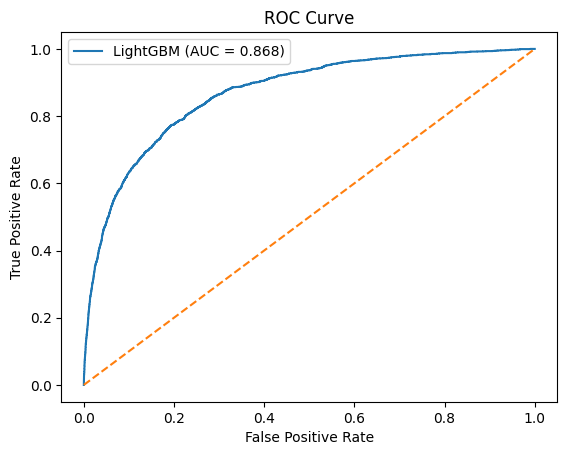

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, y_pred_lgb)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

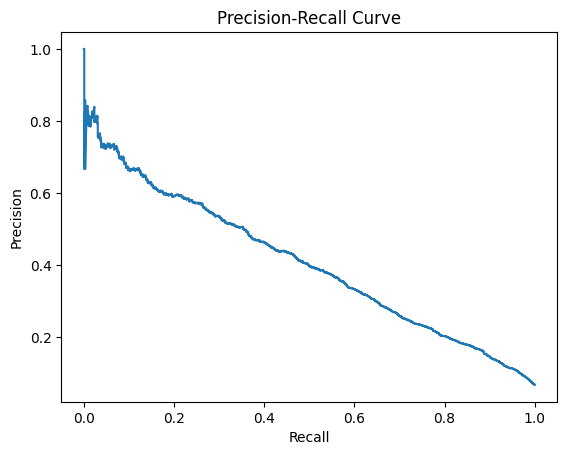

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_val, y_pred_lgb)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

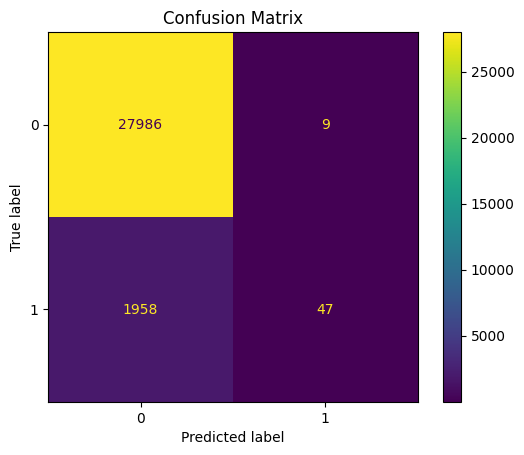

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

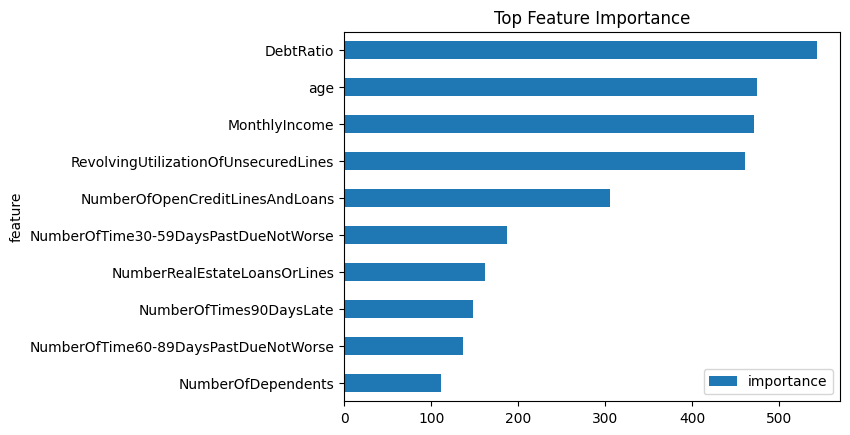

In [19]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Top 15 features
importance.head(15).plot.barh(x='feature', y='importance')

plt.title("Top Feature Importance")
plt.gca().invert_yaxis()
plt.show()

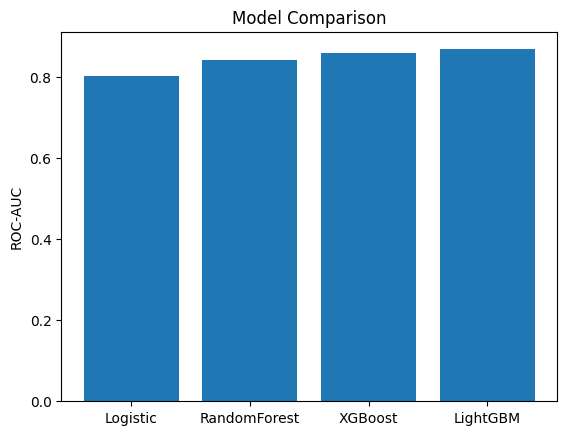

In [20]:
import matplotlib.pyplot as plt

models = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(models, scores)

plt.ylabel("ROC-AUC")
plt.title("Model Comparison")

plt.show()

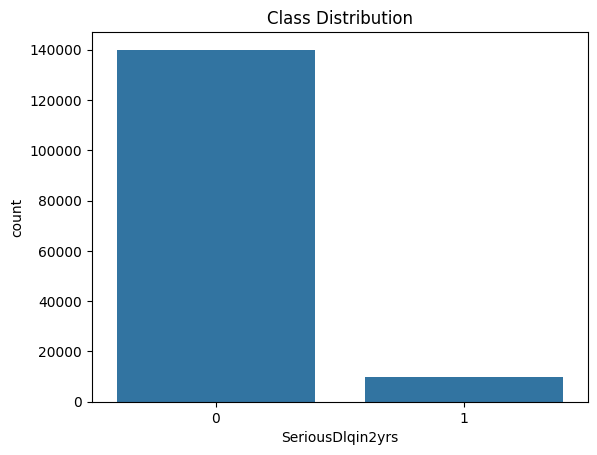

In [21]:
import seaborn as sns

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()